# College Football Top 25 Ranking Analysis

Research question: Which team statistics are most strongly related to higher AP rankings among the 2022 college football Top 25 teams?

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
import pandas as pd

df_cfb = pd.read_csv('cfb22.csv')
df_ap = pd.read_csv('ap_top25_2022 (1) (1).csv')

df_ap = df_ap.rename(columns={'Rank': 'AP Rank'})

I first cleaned the team names so the two datasets could be merged correctly.

In [27]:
df_cfb = df_cfb.drop(columns=['Unnamed: 0'])

In [28]:
df_cfb['Team'] = df_cfb['Team'].str.replace(r'\s*\(.*\)', '', regex=True)

In [29]:
df_cfb.head()
df_ap.head()

,AP Rank,Team,AP Poll Points,Wins,Losses
0,1,Georgia,1575,15,0
1,2,TCU,1490,13,2
2,3,Michigan,1400,13,1
3,4,Ohio State,1340,11,2
4,5,Alabama,1270,11,2


In [30]:
name_fixes = {
    'Ohio State': 'Ohio St.',
    'Penn State': 'Penn St.',
    'Kansas State': 'Kansas St.',
    'USC': 'Southern California',
    'Florida State': 'Florida St.',
    'Oregon State': 'Oregon St.',
    'Mississippi State': 'Mississippi St.',
    'Fresno State': 'Fresno St.'
}

df_ap['Team'] = df_ap['Team'].replace(name_fixes)

I merged the team statistics dataset with the AP Top 25 rankings dataset using the Team column.

In [31]:
df_merged = pd.merge(df_cfb, df_ap, on='Team', how='inner')
df_merged.head()

,Off Rank,Team,Games,Win-Loss,Off Plays,Off Yards,Off Yards/Play,Off TDs,Off Yards per Game,Def Rank,...,Turnovers Gain,Fumbles Lost,Interceptions Thrown_y,Turnovers Lost,Turnover Margin,Avg Turnover Margin per Game,AP Rank,AP Poll Points,Wins,Losses
0,1,Tennessee,13,11-2,945,6832,7.23,78,525.5,91,...,22,8,3,11,11,0.85,6,1180,11,2
1,2,Washington,13,11-2,975,6705,6.88,65,515.8,60,...,12,2,9,11,1,0.08,8,1040,11,2
2,3,Southern California,14,11-3,988,7092,7.18,73,506.6,106,...,29,2,5,7,22,1.57,12,840,11,3
3,4,UCLA,13,9-4,934,6547,7.01,65,503.6,87,...,18,9,12,21,-3,-0.23,17,640,9,4
4,5,Georgia,15,15-0,1049,7517,7.17,75,501.1,10,...,19,11,7,18,1,0.07,1,1575,15,0


In [32]:
df_ap.columns

Index(['AP Rank', 'Team', 'AP Poll Points', 'Wins', 'Losses'], dtype='str')

In [33]:
df_ap = pd.read_csv('ap_top25_2022 (1) (1).csv')

df_ap = df_ap.rename(columns={'Rank': 'AP Rank'})

In [34]:
df_ap = pd.read_csv('ap_top25_2022 (1) (1).csv')
df_ap = df_ap.rename(columns={'Rank': 'AP Rank'})

df_ap['Team'] = df_ap['Team'].replace(name_fixes)

df_merged = pd.merge(
    df_cfb,
    df_ap,
    on='Team',
    how='inner'
)

df_merged = df_merged.sort_values(by='AP Rank')

df_merged[['Team', 'AP Rank']].head(25)

,Team,AP Rank
4,Georgia,1
11,TCU,2
10,Michigan,3
6,Ohio St.,4
8,Alabama,5
0,Tennessee,6
14,Penn St.,7
1,Washington,8
13,Tulane,9
9,Utah,10


In [35]:
df_merged = df_merged.sort_values(by='AP Rank')
df_merged.head(25)

,Off Rank,Team,Games,Win-Loss,Off Plays,Off Yards,Off Yards/Play,Off TDs,Off Yards per Game,Def Rank,...,Turnovers Gain,Fumbles Lost,Interceptions Thrown_y,Turnovers Lost,Turnover Margin,Avg Turnover Margin per Game,AP Rank,AP Poll Points,Wins,Losses
4,5,Georgia,15,15-0,1049,7517,7.17,75,501.1,10,...,19,11,7,18,1,0.07,1,1575,15,0
11,27,TCU,15,13-2,1020,6825,6.69,70,455.0,95,...,22,8,8,16,6,0.40,2,1490,13,2
10,24,Michigan,14,13-1,970,6423,6.62,65,458.8,6,...,18,4,6,10,8,0.57,3,1400,13,1
6,9,Ohio St.,13,11-2,876,6379,7.28,72,490.7,14,...,18,4,6,10,8,0.62,4,1340,11,2
8,11,Alabama,13,11-2,896,6202,6.92,63,477.1,13,...,14,8,8,16,-2,-0.15,5,1270,11,2
0,1,Tennessee,13,11-2,945,6832,7.23,78,525.5,91,...,22,8,3,11,11,0.85,6,1180,11,2
14,34,Penn St.,13,11-2,911,5637,6.19,57,433.6,17,...,26,8,7,15,11,0.85,7,1120,11,2
1,2,Washington,13,11-2,975,6705,6.88,65,515.8,60,...,12,2,9,11,1,0.08,8,1040,11,2
13,31,Tulane,14,12-2,936,6179,6.60,64,441.4,47,...,21,11,5,16,5,0.36,9,960,12,2
9,17,Utah,14,10-4,1006,6536,6.50,69,466.9,27,...,24,8,10,18,6,0.43,10,920,10,3


In [36]:
df_merged[['Team', 'AP Rank']].head(25)

,Team,AP Rank
4,Georgia,1
11,TCU,2
10,Michigan,3
6,Ohio St.,4
8,Alabama,5
0,Tennessee,6
14,Penn St.,7
1,Washington,8
13,Tulane,9
9,Utah,10


In [37]:
df_merged.columns

Index(['Off Rank', 'Team', 'Games', 'Win-Loss', 'Off Plays', 'Off Yards',
       'Off Yards/Play', 'Off TDs', 'Off Yards per Game', 'Def Rank',
       ...
       'Turnovers Gain', 'Fumbles Lost', 'Interceptions Thrown_y',
       'Turnovers Lost', 'Turnover Margin', 'Avg Turnover Margin per Game',
       'AP Rank', 'AP Poll Points', 'Wins', 'Losses'],
      dtype='str', length=154)

The merged dataset contains 25 teams, which matches the final AP Top 25.

## Correlation Analysis

Because AP Rank assigns lower numbers to better teams, strong performance statistics are expected to have negative correlations with AP Rank. In this project, a negative correlation means that as the statistic increases, the team's AP ranking generally improves.

In [38]:
project_cols = [
    'Team',
    'AP Rank',
    'Wins',
    
    # Offense
    'Points Per Game',
    'Off Yards per Game',
    'Off Yards/Play',
    
    # Defense
    'Avg Points per Game Allowed',
    'Yards Per Game Allowed',
    
    # Efficiency
    'Turnover Margin',
    'Avg Turnover Margin per Game',
    
    # Rushing vs Passing
    'Rushing Yards per Game',
    'Pass Yards Per Game'
]

In [39]:
df_project = df_merged[project_cols]
df_project.head()

,Team,AP Rank,Wins,Points Per Game,Off Yards per Game,Off Yards/Play,Avg Points per Game Allowed,Yards Per Game Allowed,Turnover Margin,Avg Turnover Margin per Game,Rushing Yards per Game,Pass Yards Per Game
4,Georgia,1,15,41.1,501.1,7.17,14.3,296.8,1,0.07,205.3,295.8
11,TCU,2,13,38.8,455.0,6.69,29.0,408.2,6,0.40,193.3,261.7
10,Michigan,3,13,40.4,458.8,6.62,16.1,292.1,8,0.57,238.9,219.9
6,Ohio St.,4,11,44.2,490.7,7.28,21.0,321.5,8,0.62,192.4,298.3
8,Alabama,5,11,41.1,477.1,6.92,18.2,318.2,-2,-0.15,195.5,281.5


I used correlation analysis to measure which statistics had the strongest relationship with AP Rank.

In [40]:
corr = df_project.corr(numeric_only=True)

print(corr['AP Rank'].sort_values())

Points Per Game                -0.769752
Wins                           -0.738661
Off Yards/Play                 -0.690965
Off Yards per Game             -0.634314
Rushing Yards per Game         -0.484460
Avg Turnover Margin per Game   -0.296990
Turnover Margin                -0.295514
Pass Yards Per Game            -0.283635
Yards Per Game Allowed          0.099449
Avg Points per Game Allowed     0.169961
AP Rank                         1.000000
Name: AP Rank, dtype: float64


In [41]:
corr = df_project.corr(numeric_only=True)
rank_corr = corr['AP Rank'].sort_values()

The correlation table shows which statistics have the strongest relationship with AP Rank. Since a lower AP Rank is better, stronger negative correlations indicate stronger relationships with higher-ranked teams.

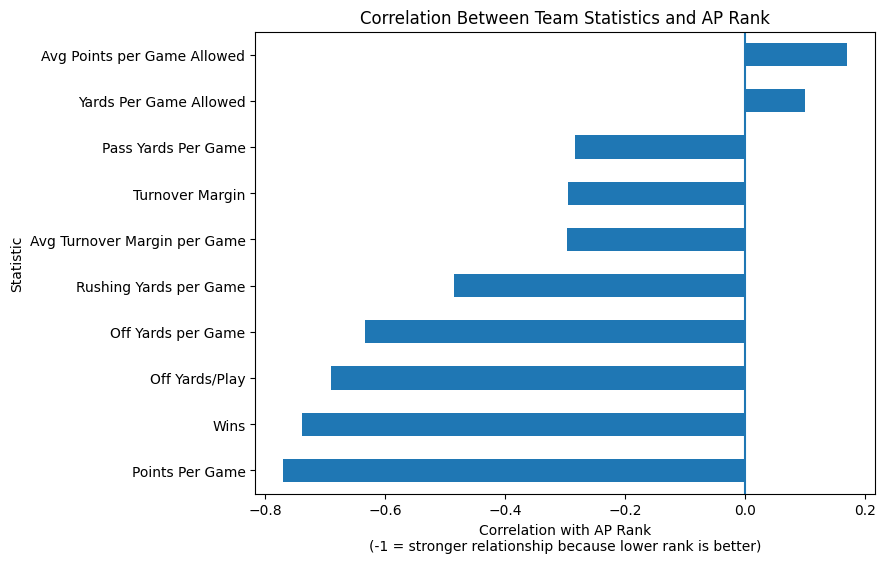

In [42]:
rank_corr.drop('AP Rank').plot(kind='barh', figsize=(8,6))

plt.title('Correlation Between Team Statistics and AP Rank')
plt.xlabel('Correlation with AP Rank\n(-1 = stronger relationship because lower rank is better)')
plt.ylabel('Statistic')
plt.axvline(0)

plt.show()

The bar chart shows that offensive statistics have the strongest relationships with AP Rank. Points Per Game, Wins, Off Yards/Play, and Off Yards per Game all have stronger correlations than the defensive statistics.

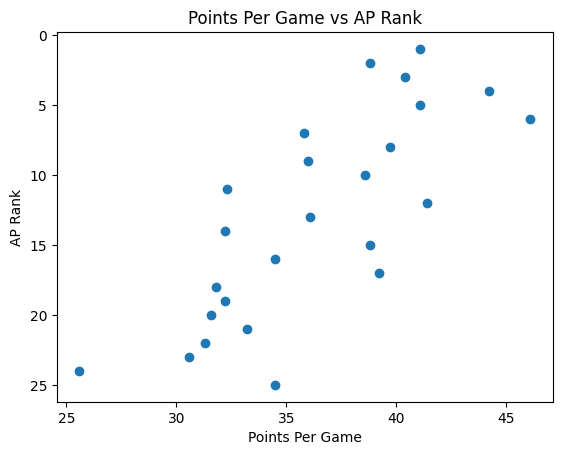

In [43]:
plt.scatter(df_project['Points Per Game'], df_project['AP Rank'])
plt.xlabel('Points Per Game')
plt.ylabel('AP Rank')
plt.title('Points Per Game vs AP Rank')
plt.gca().invert_yaxis()
plt.show()

This graph compares scoring offense with AP Rank. The y-axis is inverted so that better rankings appear higher on the graph. Teams that scored more points per game generally had better AP rankings.

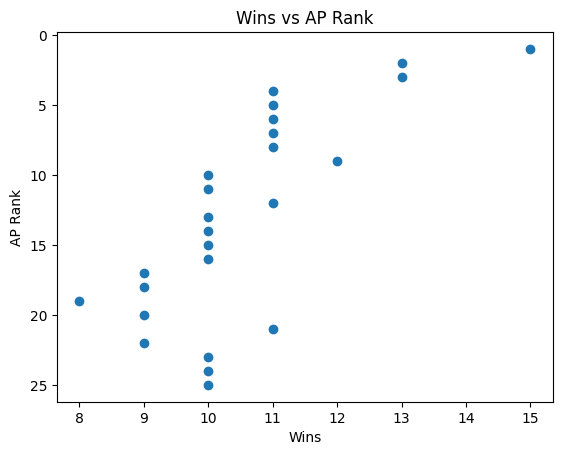

In [44]:
plt.scatter(df_project['Wins'], df_project['AP Rank'])
plt.xlabel('Wins')
plt.ylabel('AP Rank')
plt.title('Wins vs AP Rank')
plt.gca().invert_yaxis()
plt.show()

This graph compares total wins with AP Rank. Teams with more wins generally finished higher in the final AP rankings.

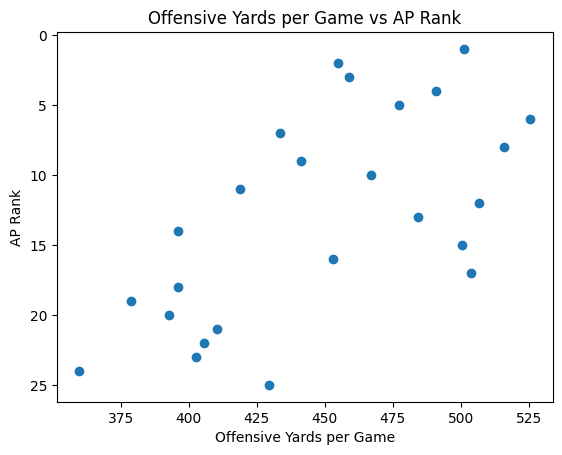

In [45]:
plt.scatter(df_project['Off Yards per Game'], df_project['AP Rank'])
plt.xlabel('Offensive Yards per Game')
plt.ylabel('AP Rank')
plt.title('Offensive Yards per Game vs AP Rank')
plt.gca().invert_yaxis()
plt.show()

This graph compares offensive yards per game with AP Rank. The relationship supports the idea that stronger offensive production is connected with higher rankings.

## Top 10 vs Bottom 15 Comparison

To add another layer to the analysis, I compared the average statistics of the top 10 ranked teams against the remaining 15 teams in the AP Top 25.

In [46]:
# Split into Top 10 and Bottom 15
top10 = df_project[df_project['AP Rank'] <= 10]
bottom15 = df_project[df_project['AP Rank'] > 10]

# Create comparison table
comparison = pd.DataFrame({
    'Top 10 Avg': top10.mean(numeric_only=True),
    'Bottom 15 Avg': bottom15.mean(numeric_only=True)
})

# Round values for cleaner output
comparison = comparison.round(2)

# Select only important stats (clean view)
comparison = comparison.loc[
    [
        'Wins',
        'Points Per Game',
        'Off Yards per Game',
        'Off Yards/Play',
        'Avg Points per Game Allowed',
        'Yards Per Game Allowed',
        'Turnover Margin',
        'Rushing Yards per Game',
        'Pass Yards Per Game'
    ]
]

comparison

,Top 10 Avg,Bottom 15 Avg
Wins,11.80,9.73
Points Per Game,40.18,33.69
Off Yards per Game,476.59,429.27
Off Yards/Play,6.81,6.22
Avg Points per Game Allowed,20.90,23.23
Yards Per Game Allowed,343.28,358.03
Turnover Margin,5.50,3.47
Rushing Yards per Game,197.44,174.32
Pass Yards Per Game,279.14,254.97


This comparison shows whether the highest-ranked teams separated themselves from the rest of the Top 25 in major statistical categories.

In [47]:
comparison.loc[
    ['Wins', 'Points Per Game', 'Off Yards per Game', 'Off Yards/Play',
     'Avg Points per Game Allowed', 'Yards Per Game Allowed',
     'Turnover Margin']
]

,Top 10 Avg,Bottom 15 Avg
Wins,11.80,9.73
Points Per Game,40.18,33.69
Off Yards per Game,476.59,429.27
Off Yards/Play,6.81,6.22
Avg Points per Game Allowed,20.90,23.23
Yards Per Game Allowed,343.28,358.03
Turnover Margin,5.50,3.47


## Conclusion

The results show that offensive performance was strongly related to AP ranking among the 2022 college football Top 25 teams. Points Per Game, Wins, Off Yards/Play, and Off Yards per Game had the strongest relationships with AP Rank. Because lower AP Rank numbers represent better rankings, these strong negative correlations show that teams with better offensive production generally finished higher in the rankings.

Defensive statistics had weaker relationships with AP Rank. Yards Per Game Allowed and Avg Points per Game Allowed were much closer to zero, meaning they were less strongly connected to ranking differences within the Top 25. Overall, the analysis suggests that AP voters rewarded winning and offensive production more strongly than defensive performance when ranking the top teams in 2022.